In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ScaleConditionedCNN
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics

# print(jax.devices("gpu"))
print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
# parts_per_dim = 64
# mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [6]:
def train_step_base(model, optimizer, loss_fn_wrapper):
    loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
    optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)

    return loss, grad_norm


@nnx.jit(static_argnames=("model_type", "pressure_architecture", "w_pos", "w_vel", "w_cls", "w_cross", "w_snapshot"))
def train_step_particle(
    y0, 
    ts, 
    ref_pos, 
    ref_cls, 
    optimizer,
    gravity_model=None,
    pressure_model=None,
    # static
    model_type="pressure",
    pressure_architecture="mlp", 
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
):
    """dynamic snapshot range as passed"""

    if model_type == "pressure":
        def loss_fn_wrapper(model):
            return particle_loss_fn(
                y0, 
                ts, 
                ref_pos, 
                ref_cls, 
                gravity_model=gravity_model, 
                pressure_model=model, 
                species="gas",
                pressure_architecture="mlp", 
                w_pos=w_pos,
                w_vel=w_vel,
                w_cls=w_cls,
                w_cross=w_cross,
                w_snapshot=w_snapshot,
            )

        return train_step_base(pressure_model, optimizer, loss_fn_wrapper)

    elif model_type == "gravity":
        def loss_fn_wrapper(model):
            return particle_loss_fn(
                y0, 
                ts, 
                ref_pos, 
                ref_cls, 
                gravity_model=model, 
                pressure_model=pressure_model, 
                species="dm",
                pressure_architecture="mlp", 
                w_pos=w_pos,
                w_vel=w_vel,
                w_cls=w_cls,
                w_cross=w_cross,
                w_snapshot=w_snapshot,
            )

        return train_step_base(gravity_model, optimizer, loss_fn_wrapper)
    
@nnx.jit(static_argnames=("architecture",))
def train_step_field(model, optimizer, y0, ts, ref_rho, ref_cls, architecture="cnn"):
    """dynamic snapshot range as passed"""
    
    def loss_fn_wrapper(model):
        return field_loss_fn(model, y0, ts, ref_rho, ref_cls, architecture, eps=1e-8)

    return train_step_base(model, optimizer, loss_fn_wrapper)

In [7]:
# def train_step_base(model, optimizer, loss_fn_wrapper):
#     loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
#     optimizer.update(grads)

#     squared_sum = jax.tree_util.tree_reduce(
#             lambda x, y: x + jnp.sum(y**2),
#             grads,
#             0.0
#         )
#     grad_norm = jnp.sqrt(squared_sum)

#     return loss, grad_norm


# @nnx.jit(static_argnames=("model_type", "pressure_architecture"))
# def train_step_particle(
#     model, 
#     optimizer, 
#     y0, 
#     ts, 
#     ref_pos, 
#     ref_cls, 
#     model_type="pressure",
#     pressure_architecture="mlp", 
# ):
#     """dynamic snapshot range as passed"""
    
#     def loss_fn_wrapper(model):
#         if model_type == "pressure":
#             return particle_loss_fn(y0, ts, ref_pos, ref_cls, pressure_model=model, pressure_architecture=pressure_architecture, eps=1e-8)
#         elif model_type == "gravity":
#             return particle_loss_fn(y0, ts, ref_pos, ref_cls, gravity_model=model, eps=1e-8)
    
#     return train_step_base(model, optimizer, loss_fn_wrapper)
    
# @nnx.jit(static_argnames=("architecture",))
# def train_step_field(model, optimizer, y0, ts, ref_rho, ref_cls, architecture="cnn"):
#     """dynamic snapshot range as passed"""
    
#     def loss_fn_wrapper(model):
#         return field_loss_fn(model, y0, ts, ref_rho, ref_cls, architecture, eps=1e-8)

#     return train_step_base(model, optimizer, loss_fn_wrapper)

In [8]:
# dt0 = 0.001
# dt0 = 0.1
dt0 = 0.01
# dt0 = 0.005

scales = train_dict["scales"]
print(np.diff(scales))
# assert np.all(np.diff(scales) > dt0)

edges = graph.get_edges(train_dict["gas_poss"], scales, k=4)

def solve_ode(y0, ts, gravity_model, pressure_model, architecture, training=True):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            gravity_model=gravity_model, 
            pressure_model=pressure_model, 
            gas_architecture=architecture, 
            precomputed_edges=edges,
            training=training,
        )
    )

    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=ts[0],
            t1=ts[-1],
            dt0=dt0,
            y0=y0,
            saveat=SaveAt(ts=ts),
            max_steps=1000,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res


[0.02380952 0.03333333 0.02222222 0.02777778 0.01224106 0.01284044
 0.01346916 0.01412867 0.01482047 0.01554614 0.01630734 0.01710582
 0.0179434  0.01882198 0.01974359 0.02071031 0.02172438 0.0227881
 0.0239039  0.02507434 0.02630208 0.02758995 0.02894087 0.03035793
 0.03184439 0.03340362 0.03503921 0.03675488 0.03855455 0.04044235
 0.04242258 0.04449977 0.04667867]


# loss

### CAMELS ground truth

In [9]:
# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass
rho_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
rho_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# power spectrum
vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
_, cls_dm = vpower_spectrum(rho_dm)
_, cls_gas = vpower_spectrum(rho_gas)

# cross correlation coefficient
vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
# vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [10]:
# # velocity
# vel_mean_ref = jax.vmap(
#     jax.vmap(
#         cic_paint, 
#         in_axes=(None,0,0)
#     ),
#     in_axes=(None,None,-1), out_axes=-1,
# )(jnp.zeros(mesh_shape), ref_pos, ref_vel / ref_N[..., jnp.newaxis])

# ref_vel_mean = jax.vmap(
#     jax.vmap(
#         cic_read, 
#         in_axes=(0,0)
#     ),
#     in_axes=(-1,None), out_axes=-1,
# )(vel_mean_ref, ref_pos)

# ref_vel_disp = jnp.sum((ref_vel_mean - ref_vel) ** 2, axis=-1)

### particle-level

In [11]:
def particle_loss_fn(
    y0, 
    ts, 
    ref_pos, 
    ref_cls,
    species="gas",
    gravity_model=None, 
    pressure_model=None, 
    pressure_architecture="mlp", 
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
    eps=1e-8,
    # w_snapshot=1/jnp.maximum(scales[:, jnp.newaxis]**3, eps),
):
    print("using particle loss")
    
    # integrate
    res = solve_ode(y0, ts, gravity_model, pressure_model, pressure_architecture)
    if species == "dm":
        res_poss, res_vels = res[0], res[1]
        particle_mass = dm_mass
    elif species == "gas":
        res_poss, res_vels = res[2], res[3]
        particle_mass = gas_mass
    else:
        raise NotImplementedError
    
    # position
    if w_pos > 0.0:
        print(f"w_pos = {w_pos}") 
        delta_pos = ((res_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
        pos_loss = jnp.sum(delta_pos**2, axis=-1)
        if w_snapshot > 0.0:
            pos_loss *= w_snapshot
        pos_loss = jnp.mean(pos_loss)
    else:
        pos_loss = 0.0

    # velocity
    if w_vel > 0.0:
        print(f"w_vel = {w_vel}") 
        vel_loss = jnp.sum((res_vels - ref_vel)**2, axis=-1)
        vel_loss = jnp.where(vel_loss < mesh_per_dim//2, vel_loss, 0.0)
        if w_snapshot > 0.0:
            vel_loss *= w_snapshot
        vel_loss = jnp.mean(vel_loss)
    else:
        vel_loss = 0.0

    # power spectrum
    if w_cls > 0.0:
        print(f"w_cls = {w_cls}") 
        res_rho = vcic_paint(jnp.zeros(mesh_shape), res_poss, particle_mass)
        kbins, res_cls = vpower_spectrum(res_rho)
    
        k = kbins[0]
        k_min, k_cutoff = k[0], k[int(0.2*len(k))]
        k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)
    
        cls_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)
        if w_snapshot > 0.0:
            cls_loss *= w_snapshot
        cls_loss = jnp.mean(cls_loss)
    else:
        cls_loss = 0.0

    # cross correlation
    if w_cross > 0.0:
        print(f"w_cross = {w_cross}") 
        _, res_cross = vcross_correlation(res_rho)
        cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))
        if w_snapshot > 0.0:
            cross_loss *= w_snapshot
        cross_loss = jnp.mean(cross_loss)
    else:
        cross_loss = 0.0

    return w_pos * pos_loss + w_vel * vel_loss + w_cls * cls_loss + w_cross * cross_loss


### field-level

In [12]:
# def field_loss_fn(model, y0, ts, ref_rho, ref_cls, architecture, eps=1e-8):
#     print("using field loss")
    
#     res = solve_ode(model, y0, ts, architecture)
#     gas_poss = res[2]%mesh_per_dim
#     gas_vels = res[3]

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     rho_loss = (res_rho - ref_rho)**2
#     # rho_loss /= jnp.maximum(scales.reshape(-1,1,1,1)**2, eps)
#     rho_loss = jnp.mean(rho_loss)

#     kbins, res_cls = vpower_spectrum(res_rho)
#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)
#     # cl_loss /= jnp.maximum(scales[:,jnp.newaxis]**3, eps)
#     cl_loss = jnp.mean(cl_loss)
        
#     return rho_loss + 0.1 * cl_loss
    

In [13]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim

#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
        
#     eps = 1e-5
#     # rho_loss = jnp.mean((jnp.log1p(rho + eps) - jnp.log1p(ref_rho + eps))**2)
#     # rho_loss = jnp.mean((jnp.log10(rho - ref_rho + eps))**2)
    
#     rho_loss = jnp.mean(jnp.sum((rho - ref_rho)**2, axis=(1,2,3)))

#     # _, res_cls = vpower_spectrum(res_rho)
#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
    
#     return rho_loss
#     # return rho_loss + 0.1 * cl_loss


In [14]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim
    
#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    
#     eps = 1e-8
#     log_rho = jnp.log10(rho + eps)
#     log_ref_rho = jnp.log10(ref_rho + eps)
#     # log_loss = jnp.mean(jnp.sum((log_rho - log_ref_rho)**2, axis=(1,2,3)))
#     log_loss = jnp.mean((log_rho - log_ref_rho)**2)
        
#     return log_loss

# fit gravity correction

In [15]:
i_plots = range(0, 32+8, 8)

In [16]:
gravity_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))

In [17]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/gravity_fourier_spline_v1.jx")
# checkpointer = ocp.StandardCheckpointer()

# try:
#     abstract_model = nnx.eval_shape(lambda: gravity_model)
#     graphdef, abstract_params = nnx.split(abstract_model)
    
#     params = checkpointer.restore(checkpoint_file, abstract_params)
#     gravity_model = nnx.merge(graphdef, params)
#     print(f"successfully restored model from {checkpoint_file}")
# except:
#     print("failed to load model")

## training

In [18]:
total_steps = 300
learning_rate = 1e-3
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

gravity_optimizer = nnx.ModelAndOptimizer(
    gravity_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grad_norms = []

  0%|          | 0/300 [00:00<?, ?it/s]

using particle loss
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential
w_pos = 1.0
w_cls = 0.1


Loss: 0.2932: 100%|██████████| 300/300 [07:45<00:00,  1.55s/it]


[None]

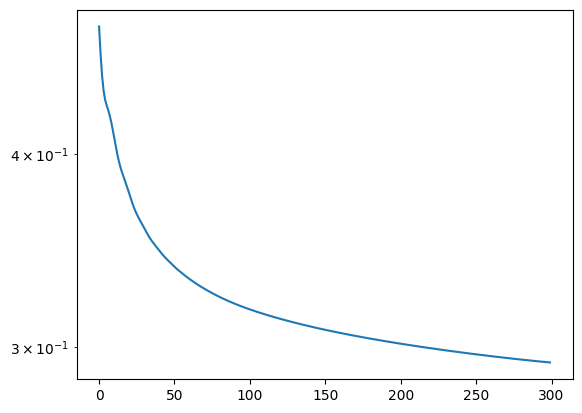

In [19]:
# evaluating the loss for all snapshots is computationally feasible
for i in (pbar := tqdm.tqdm(range(total_steps))):
    y0 = (dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0])
    
    loss, grad_norm = train_step_particle(
        y0, 
        scales,
        dm_poss, 
        cls_dm,
        gravity_optimizer, 
        gravity_model=gravity_model,
        pressure_model=None,
        model_type="gravity",
        w_cls=0.1,
    )

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

In [20]:
# _, params = nnx.split(gravity_model)
# checkpointer.save(checkpoint_file, params, force=True)

In [25]:
dt0

0.005

In [26]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model, 
        dt0=dt0,
        # i_snapshots=None,
        i_snapshots=i_plots,
        # i_snapshots=i_snapshots,
        # i_snapshots = range(1, 33+8, 8),
        # i_snapshots = range(1, 33+4, 4),
        plot_dm=True,
        plot_gas=False,
    )

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential


E0813 08:20:38.598957 2270140 pjrt_stream_executor_client.cc:2939] Execution of replica 0 failed: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/runpy.py", line 198, in _run_module_as_main
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/runpy.py", line 88, in _run_code
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/asy

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/tornado/platform/

# fit pressure correction

### MLP

In [35]:
pressure_model = MLP(
    d_in=5,
    d_out=1, 
    # d_hidden=16, 
    # d_hidden=64, 
    d_hidden=128,
    # d_hidden=256,
    # n_hidden=4, 
    n_hidden=2, 
    # dropout_rate=0.01,
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="layer",
    # norm_type="batch",
    activation=jax.nn.swish,
)
architecture = "mlp"

### CNN

In [36]:
# model = ScaleConditionedCNN(
#     d_in=4 + latent_dim, 
#     d_out=1 + latent_dim,
#     d_hidden=64,
#     # d_hidden=128,
#     # d_hidden=256,
#     # n_hidden=4,
#     n_hidden=4,
#     kernel_size=(3, 3, 3),
#     rngs=nnx.Rngs(0),
#     norm_type="layer",
#     activation=jax.nn.swish,
# )

# architecture = "cnn"

## training

In [37]:
def train_step_wrapper(i_step=None):
    if i_step is None:
        i_step = np.arange(0, len(scales))

    i0, i1 = i_step[0], i_step[-1]    
    ts = scales[i_step]
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])

    if architecture in ["mlp"]:
        loss, grad_norm = train_step_particle(
            y0, 
            scales[i_step], 
            gas_poss[i_step], 
            cls_gas[i_step],
            pressure_optimizer, 
            pressure_model=pressure_model,
            gravity_model=gravity_model,
            pressure_architecture=architecture,
            model_type="pressure",
            w_cls=0.1,
        )
    elif architecture in ["cnn"]:
        loss, grad_norm = train_step_field(
            y0, 
            scales[i_step], 
            rho_gas[i_step],
            cls_gas[i_step],
            pressure_optimizer, 
            pressure_model=pressure_model,
            gravity_model=gravity_model,
            model_type="pressure",
        )
    else:
        raise NotImplementedError

    losses.append(float(loss))
    grad_norms.append(float(grad_norm))
    # pbar.set_description(f"Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}, {i_step}")
    pbar.set_description(f"Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")

def plot_training(losses, grad_norms):
    fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
    ax[0].plot(losses)
    ax[0].set(yscale="log", title="loss")
    
    ax[1].plot(grad_norms)
    ax[1].set(yscale="log", title="norm(grad)")

In [38]:
total_steps = 500

# learning_rate = 1e-3
# learning_rate = 5e-4
learning_rate = 1e-4
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-4, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-4,
#     peak_value=1e-3,
#     end_value=1e-5,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
clip_norm = 1

pressure_optimizer = nnx.ModelAndOptimizer(
    pressure_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
        # optax.ema(decay=0.999),
        # optax.adamw(learning_rate, b1=0.95, b2= 0.9999, eps=1e-5)
        # optax.adamw(learning_rate, eps=1e-5)
    )
)

losses = []
grad_norms = []

In [39]:
i_snapshots = np.arange(-4, 0, dtype=int)
# i_snapshots = np.arange(-8, 0, dtype=int)
# i_snapshots = np.arange(0, 8, dtype=int)

## fixed snapshots

### all

In [40]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper()
# plot_training(losses, grad_norms)

### subset

In [40]:
for i in (pbar := tqdm.tqdm(range(total_steps))):
    train_step_wrapper(i_snapshots)
plot_training(losses, grad_norms)

  0%|          | 0/500 [00:00<?, ?it/s]

using particle loss
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
w_pos = 1.0
w_cls = 0.1


Loss: 4.6920e-02, Grad norm: 1.9414e-02:  45%|████▍     | 224/500 [02:05<02:34,  1.79it/s]


KeyboardInterrupt: 

KeyboardInterrupt: 

## random snapshots

### spaced

In [ ]:
# i_base = np.arange(0, 32, 4)
# i_delta = 6

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_shift = np.random.randint(0, i_delta)
#     i_step = i_base + i_shift

#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### continuous

In [ ]:
# i_delta = 8

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_rand = np.random.randint(0, len(scales) - i_delta)
#     i_step = np.arange(i_rand, i_rand + i_delta)
    
#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### checkpointing

In [ ]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v1_late_time.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v2.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_illustris_v1.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v4_full.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [ ]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [ ]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

In [ ]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model,
        pressure_model=pressure_model, 
        gas_architecture=architecture, 
        dt0=dt0,
        # i_snapshots=None,
        i_snapshots=i_plots,
        # i_snapshots=i_snapshots,
        # i_snapshots = range(1, 33+8, 8),
        # i_snapshots = range(0, 32+8, 8),
        # i_snapshots = range(1, 33+4, 4),
        plot_dm=True,
        plot_gas=True,
    )